# Evaluation & Insights

---

## Goal
Explain what the model learned, translate predictions into business
actions, document findings honestly, and produce final deliverables.

## What we load
The trained models and test data from Day 2 cannot be passed between
notebooks directly. We reload the feature table, retrain the best model,
and rebuild all evaluation outputs cleanly.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, roc_auc_score,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (10, 5)

print("Libraries ready.")

c:\Users\Charles\Documents\ecom-churn-predictor\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries ready.


In [2]:
rfm = pd.read_csv('../data/processed/features_and_labels.csv')

print(f"Feature table shape: {rfm.shape}")
print(f"Churn rate: {rfm['churned'].mean():.1%}")
print(f"\nColumns: {list(rfm.columns)}")

Feature table shape: (93358, 13)
Churn rate: 79.9%

Columns: ['customer_unique_id', 'recency', 'frequency', 'monetary', 'avg_order_value', 'customer_lifespan_days', 'unique_categories', 'total_items', 'avg_review_score', 'review_count', 'avg_installments', 'used_credit_card', 'churned']


In [3]:
drop_cols = ['customer_unique_id', 'churned']
X = rfm.drop(columns=drop_cols)
y = rfm['churned']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

neg   = (y_train == 0).sum()
pos   = (y_train == 1).sum()
scale = neg / pos

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    eval_metric='auc',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train, y_train)

y_pred_xgb  = xgb.predict(X_test)
y_proba_xgb = xgb.predict_proba(X_test)[:, 1]

print(f"XGBoost retrained.")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

XGBoost retrained.
ROC-AUC: 1.0000


---
## Sprint 7 — Model Evaluation and Explainability

### Why explainability matters
A model that outputs a number is not a business tool.
A model that says "this customer is at risk BECAUSE they have not
purchased in 180 days AND their average order value dropped" is actionable.

SHAP (SHapley Additive Explanations) tells us for each customer:
- Which features pushed the prediction toward churned
- Which features pushed it toward active
- How strongly each feature influenced the final score

This is what turns a black-box model into a decision-support tool.

In [4]:
explainer   = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)

print(f"SHAP values shape: {shap_values.shape}")
print(f"One row per test customer, one column per feature.")
print(f"\nFeatures: {list(X.columns)}")

SHAP values shape: (18672, 11)
One row per test customer, one column per feature.

Features: ['recency', 'frequency', 'monetary', 'avg_order_value', 'customer_lifespan_days', 'unique_categories', 'total_items', 'avg_review_score', 'review_count', 'avg_installments', 'used_credit_card']


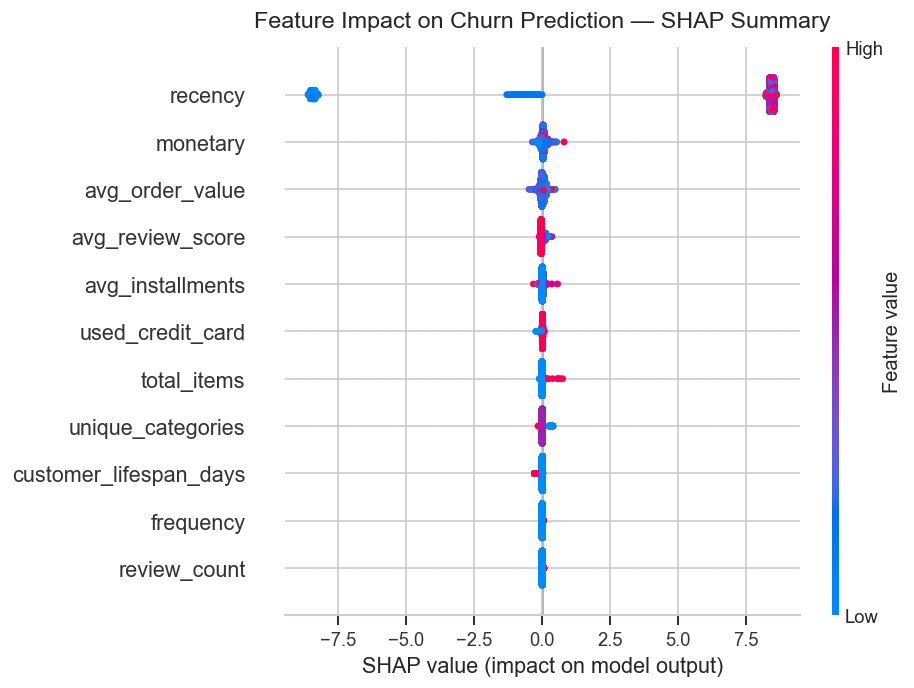

In [5]:
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns.tolist(),
    show=False
)
plt.title('Feature Impact on Churn Prediction — SHAP Summary',
          fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('../reports/figures/07_shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()

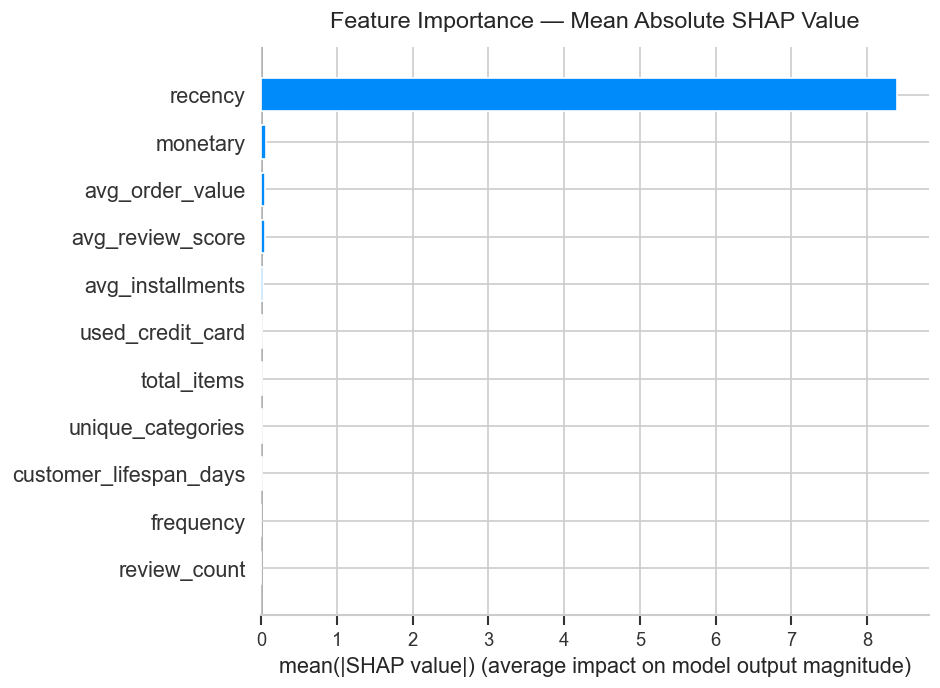

In [6]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns.tolist(),
    plot_type='bar',
    show=False
)
plt.title('Feature Importance — Mean Absolute SHAP Value',
          fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('../reports/figures/08_shap_importance.png', dpi=150, bbox_inches='tight')
plt.show()

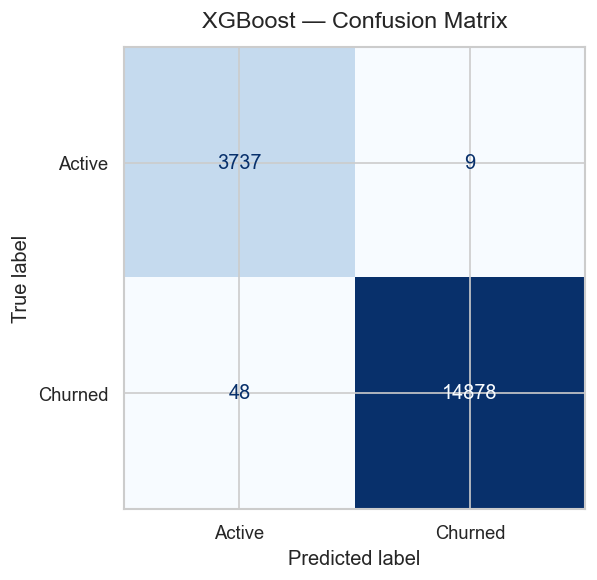

True Positives  — correctly caught churners:      14,878
True Negatives  — correctly kept as active:       3,737
False Positives — active customers flagged wrong: 9
False Negatives — churners we missed:             48

Of all real churners, we caught: 99.7%
Of all our churn flags, how many were right: 99.9%


In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

cm   = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Active', 'Churned']
)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('XGBoost — Confusion Matrix', fontsize=14, pad=12)

plt.tight_layout()
plt.savefig('../reports/figures/09_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Positives  — correctly caught churners:      {tp:,}")
print(f"True Negatives  — correctly kept as active:       {tn:,}")
print(f"False Positives — active customers flagged wrong: {fp:,}")
print(f"False Negatives — churners we missed:             {fn:,}")
print(f"\nOf all real churners, we caught: {tp/(tp+fn):.1%}")
print(f"Of all our churn flags, how many were right: {tp/(tp+fp):.1%}")

In [8]:
risk_scores = rfm[['customer_unique_id']].copy()
risk_scores['churn_probability'] = xgb.predict_proba(X)[:, 1]
risk_scores['churned_actual']    = y.values

def assign_tier(prob):
    if prob >= 0.75:
        return 'High Risk'
    elif prob >= 0.50:
        return 'Medium Risk'
    elif prob >= 0.25:
        return 'Low Risk'
    else:
        return 'Loyal'

risk_scores['risk_tier'] = risk_scores['churn_probability'].apply(assign_tier)

tier_summary = (
    risk_scores
    .groupby('risk_tier')
    .agg(
        customer_count    = ('customer_unique_id', 'count'),
        avg_churn_prob    = ('churn_probability', 'mean')
    )
    .reset_index()
    .sort_values('avg_churn_prob', ascending=False)
)

print("Customer Risk Tier Summary:")
print(tier_summary.to_string(index=False))

risk_scores.to_csv('../data/processed/customer_risk_scores.csv', index=False)
print("\nSaved to data/processed/customer_risk_scores.csv")

Customer Risk Tier Summary:
  risk_tier  customer_count  avg_churn_prob
  High Risk           74367        0.999758
Medium Risk              96        0.604286
   Low Risk             205        0.354803
      Loyal           18690        0.001224

Saved to data/processed/customer_risk_scores.csv


In [9]:
print("Sprint 7 complete.")
print("\nFiles saved:")
print("  reports/figures/07_shap_summary.png")
print("  reports/figures/08_shap_importance.png")
print("  reports/figures/09_confusion_matrix.png")
print("  data/processed/customer_risk_scores.csv")

Sprint 7 complete.

Files saved:
  reports/figures/07_shap_summary.png
  reports/figures/08_shap_importance.png
  reports/figures/09_confusion_matrix.png
  data/processed/customer_risk_scores.csv
